<a href="https://colab.research.google.com/github/Atharv-000/Object-Character-Recognition/blob/main/PRJ10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Check if drive is already mounted
import os

if os.path.exists('/content/drive/MyDrive'):
    print("✅ Drive already mounted and working!")
else:
    from google.colab import drive
    drive.mount('/content/drive')
    print("✅ Drive mounted fresh!")

✅ Drive already mounted and working!


In [ ]:
# Cell 2 - verify GPU
!nvidia-smi | head -10

Sun Apr 12 09:34:14 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   77C    P0             31W /   70W |     329MiB /  15360MiB |      0%      Default |


In [ ]:
# Cell 3 - clone YOLOv5
%cd /content
!git clone https://github.com/ultralytics/yolov5
%cd /content/yolov5
!pip install -r requirements.txt -q
import torch
print("✅ GPU:", torch.cuda.is_available())
print("✅ YOLOv5 ready!")

/content
fatal: destination path 'yolov5' already exists and is not an empty directory.
/content/yolov5
✅ GPU: True
✅ YOLOv5 ready!


In [ ]:
!pip install ultralytics -q
from ultralytics import YOLO
import torch
print("✅ YOLOv8 ready!")
print("✅ GPU:", torch.cuda.is_available())

✅ YOLOv8 ready!
✅ GPU: True


In [ ]:
import os, glob, cv2
import numpy as np

base = '/content/drive/MyDrive/Custom_OCR'
img_dir = f'{base}/dataset/images'
lbl_dir = f'{base}/dataset/labels'
os.makedirs(lbl_dir, exist_ok=True)

def find_table_bounds(img_path):
    img  = cv2.imread(img_path)
    h, w = img.shape[:2]
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Find dark header band (TEST NAME row)
    header_y = None
    for y in range(int(h*0.10), int(h*0.70)):
        row = gray[y, int(w*0.05):int(w*0.95)]
        if np.mean(row) < 110:
            header_y = y
            break

    if header_y is None:
        header_y = int(h * 0.28)

    # Tight data region — only actual rows, no footnotes
    data_y1 = header_y + int(h * 0.04)
    data_y2 = header_y + int(h * 0.25)
    data_y1 = max(0, min(data_y1, h-1))
    data_y2 = max(0, min(data_y2, h-1))
    return data_y1, data_y2, h, w

def make_label(img_path, lbl_path):
    data_y1, data_y2, h, w = find_table_bounds(img_path)
    yc = ((data_y1 + data_y2) / 2) / h
    bh = (data_y2 - data_y1) / h

    cols = [
        (0, 0.00, 0.35),  # test_name
        (1, 0.35, 0.54),  # technology
        (2, 0.54, 0.63),  # value
        (3, 0.63, 0.73),  # units
        (4, 0.73, 1.00),  # normal_range
    ]
    lines = []
    for cls_id, x1r, x2r in cols:
        xc = (x1r + x2r) / 2
        bw = x2r - x1r
        lines.append(f"{cls_id} {xc:.6f} {yc:.6f} {bw:.6f} {bh:.6f}")

    with open(lbl_path, 'w') as f:
        f.write('\n'.join(lines))

images = glob.glob(f'{img_dir}/*.jpg') + glob.glob(f'{img_dir}/*.png')
for img_path in images:
    name = os.path.splitext(os.path.basename(img_path))[0]
    make_label(img_path, f'{lbl_dir}/{name}.txt')

print(f"✅ {len(images)} labels regenerated!")

✅ 100 labels regenerated!


In [ ]:
import shutil, random, yaml

# YOLOv8 folder structure
for folder in ['images/train','images/val','labels/train','labels/val']:
    os.makedirs(f'{base}/yolov8_dataset/{folder}', exist_ok=True)

# Split 80/20
random.shuffle(images)
split     = int(0.8 * len(images))
train_imgs = images[:split]
val_imgs   = images[split:]

def copy_split(img_list, split_name):
    for img_path in img_list:
        name = os.path.splitext(os.path.basename(img_path))[0]
        ext  = os.path.splitext(img_path)[1]
        lbl  = f'{lbl_dir}/{name}.txt'
        shutil.copy(img_path,
                    f'{base}/yolov8_dataset/images/{split_name}/{name}{ext}')
        if os.path.exists(lbl):
            shutil.copy(lbl,
                        f'{base}/yolov8_dataset/labels/{split_name}/{name}.txt')

copy_split(train_imgs, 'train')
copy_split(val_imgs,   'val')
print(f"✅ Train: {len(train_imgs)} | Val: {len(val_imgs)}")

# Create dataset yaml
data = {
    'path' : f'{base}/yolov8_dataset',
    'train': 'images/train',
    'val'  : 'images/val',
    'nc'   : 5,
    'names': ['test_name','technology','value','units','normal_range']
}
yaml_path = f'{base}/yolov8_dataset/thyrocare.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(data, f, default_flow_style=False)
print("✅ thyrocare.yaml created!")

✅ Train: 80 | Val: 20
✅ thyrocare.yaml created!


In [ ]:
from ultralytics import YOLO

# Use YOLOv8n (nano) — fast and accurate enough for this task
model = YOLO('yolov8n.pt')

results = model.train(
    data    = f'{base}/yolov8_dataset/thyrocare.yaml',
    epochs  = 50,
    imgsz   = 640,
    batch   = 16,
    name    = 'thyrocare_v8',
    project = f'{base}/models',
    exist_ok= True,
    patience= 10,
    device  = 0
)
print("🎉 YOLOv8 training complete!")

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Custom_OCR/yolov8_dataset/thyrocare.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=thyrocare_v8, nbs=64, nms=False, opset=None, optimize=False, optimizer=a

In [ ]:
import os, glob, cv2
!sudo apt install tesseract-ocr
!pip install pytesseract -q

from ultralytics import YOLO
import cv2, pytesseract
import pandas as pd
import numpy as np

# Load trained model
model = YOLO(f'{base}/models/thyrocare_v8/weights/best.pt')
print("✅ YOLOv8 model loaded!")

col_names = ['test_name','technology','value','units','normal_range']

def preprocess_crop(crop):
    """Exact preprocessing from PDF"""
    crop  = cv2.resize(crop, None, fx=3, fy=3,
                       interpolation=cv2.INTER_CUBIC)
    gray  = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
    blur  = cv2.GaussianBlur(gray, (5,5), 0)
    _, th = cv2.threshold(blur, 0, 255,
                          cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    return cv2.bitwise_not(th)

def run_ocr(image_path):
    img     = cv2.imread(image_path)
    h, w    = img.shape[:2]
    results = model(image_path, conf=0.3, verbose=False)

    boxes = results[0].boxes
    if boxes is None or len(boxes) == 0:
        print("⚠️ No detections")
        return None

    print(f"✅ {len(boxes)} regions detected:")

    # Crop each detected region
    crops_list = []
    for box in boxes:
        x1,y1,x2,y2 = map(int, box.xyxy[0].tolist())
        cls_id       = int(box.cls[0])
        cls_name     = col_names[cls_id]
        conf         = float(box.conf[0])

        x1 = max(0,x1); y1 = max(0,y1)
        x2 = min(w,x2); y2 = min(h,y2)

        crop = img[y1:y2, x1:x2]
        print(f"   → {cls_name} (conf={conf:.2f}) @ ({x1},{y1})→({x2},{y2})")
        crops_list.append({'class': cls_name, 'crop': crop})

    # Pass crops through Tesseract
    col_texts = {n: '' for n in col_names}
    for item in crops_list:
        processed = preprocess_crop(item['crop'])
        text      = pytesseract.image_to_string(
            processed, config='--psm 6 --oem 3'
        ).strip()
        col_texts[item['class']] = text
        print(f"   Tesseract [{item['class']}]: {text[:50]}")

    # Split into rows and build DataFrame
    col_rows = {}
    max_rows = 0
    for name in col_names:
        lines = [l.strip() for l in col_texts[name].split('\n')
                 if l.strip() and len(l.strip()) > 1]
        col_rows[name] = lines
        max_rows = max(max_rows, len(lines))

    for name in col_names:
        while len(col_rows[name]) < max_rows:
            col_rows[name].append('')

    df = pd.DataFrame(col_rows, columns=col_names)
    df = df[df['test_name'].str.len() > 2]
    df = df[df['test_name'].str.contains('[A-Za-z]', regex=True)]
    df = df[~df['test_name'].str.upper().str.contains('TEST NAME')]
    df = df.reset_index(drop=True)
    return df

print("✅ Full pipeline ready!")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 42 not upgraded.
✅ YOLOv8 model loaded!
✅ Full pipeline ready!


In [ ]:
for test_img in random.sample(images, 3):
    print(f"\n{'='*55}")
    print(f"🔍 {os.path.basename(test_img)}")
    print('='*55)
    df = run_ocr(test_img)
    if df is not None and not df.empty:
        print(f"\n📊 {len(df)} rows extracted:")
        print(df.to_string(index=False))
        df.to_csv(
            f'{base}/results/{os.path.basename(test_img)}.csv',
            index=False)
        print("✅ CSV saved!")
    else:
        print("⚠️ No output")


🔍 thyrocare_0_1861.jpg
✅ 7 regions detected:
   → technology (conf=0.69) @ (360,369)→(577,470)
   → normal_range (conf=0.67) @ (789,367)→(1067,467)
   → units (conf=0.60) @ (679,367)→(790,477)
   → test_name (conf=0.59) @ (1,369)→(355,478)
   → value (conf=0.58) @ (573,364)→(676,473)
   → technology (conf=0.46) @ (360,194)→(585,336)
   → value (conf=0.39) @ (585,197)→(688,333)
   Tesseract [technology]: PHOTOME
PHOTOME
CALCULAT
'GGT) PHOTOME
   Tesseract [normal_range]: maq/dl 0.3-1.2
mg/dl < O.%
ma/di 0-0.9
U/I < 55
   Tesseract [units]: 0.57
0.18
0.39
34.3
Ay «¢
   Tesseract [test_name]: BILIRUBIN - TOTAL

BILIRUBIN -DIRECT

BILIRUBIN (I
   Tesseract [value]: TRY
TRY
ED

TRY
   Tesseract [technology]: (S8Y/M)
   Tesseract [value]: SAMPI
(78243
LAB, BI

📊 4 rows extracted:
                 test_name technology   value units   normal_range
         BILIRUBIN - TOTAL    (S8Y/M)   SAMPI  0.57 maq/dl 0.3-1.2
         BILIRUBIN -DIRECT             (78243  0.18    mg/dl < O.%
      BILIRUB

In [ ]:
import pandas as pd
import glob, os
from openpyxl import Workbook
from openpyxl.styles import PatternFill, Font, Alignment

base = '/content/drive/MyDrive/Custom_OCR'
images = glob.glob(f'{base}/dataset/images/*.jpg')
images += glob.glob(f'{base}/dataset/images/*.png')

all_results = []
failed = []

print(f"🔍 Processing {len(images)} images...\n")

for i, img_path in enumerate(images):
    img_name = os.path.basename(img_path)
    print(f"[{i+1}/{len(images)}] {img_name}", end=' → ')
    try:
        df = run_ocr(img_path)
        if df is not None and not df.empty:
            df['source_image'] = img_name
            all_results.append(df)
            print(f"✅ {len(df)} rows")
        else:
            failed.append(img_name)
            print("⚠️ No data")
    except Exception as e:
        failed.append(img_name)
        print(f"❌ Error: {str(e)[:40]}")

# Combine all results
if all_results:
    final_df = pd.concat(all_results, ignore_index=True)

    # ── Save to CSV ──
    csv_path = f'{base}/results/all_results.csv'
    final_df.to_csv(csv_path, index=False)
    print(f"\n✅ CSV saved: {csv_path}")

    # ── Save to Excel with formatting ──
    xlsx_path = f'{base}/results/all_results.xlsx'
    wb = Workbook()
    ws = wb.active
    ws.title = "Lab Results"

    # Header style
    header_fill = PatternFill(start_color="2E4057",
                              end_color="2E4057",
                              fill_type="solid")
    header_font = Font(color="FFFFFF", bold=True, size=11)

    # Write headers
    headers = ['test_name','technology','value','units',
               'normal_range','source_image']
    for col, header in enumerate(headers, 1):
        cell = ws.cell(row=1, column=col, value=header.upper())
        cell.fill      = header_fill
        cell.font      = header_font
        cell.alignment = Alignment(horizontal='center')

    # Write data
    alt_fill = PatternFill(start_color="F2F2F2",
                           end_color="F2F2F2",
                           fill_type="solid")
    for row_idx, row in final_df.iterrows():
        for col_idx, col in enumerate(headers, 1):
            val  = str(row.get(col, ''))
            cell = ws.cell(row=row_idx+2, column=col_idx, value=val)
            cell.alignment = Alignment(horizontal='left')
            if row_idx % 2 == 0:
                cell.fill = alt_fill

    # Auto column width
    for col in ws.columns:
        max_len = max(len(str(c.value or '')) for c in col)
        ws.column_dimensions[col[0].column_letter].width = min(max_len+4, 40)

    wb.save(xlsx_path)
    print(f"✅ Excel saved: {xlsx_path}")
    print(f"\n📊 Summary:")
    print(f"   Total images processed : {len(images)}")
    print(f"   Successfully extracted : {len(all_results)}")
    print(f"   Failed                 : {len(failed)}")
    print(f"   Total rows extracted   : {len(final_df)}")
else:
    print("❌ No results extracted from any image")
    print(f"Failed images: {failed[:5]}")

🔍 Processing 100 images...

[1/100] thyrocare_0_36.jpg → ✅ 4 regions detected:
   → normal_range (conf=0.61) @ (463,615)→(635,798)
   → test_name (conf=0.57) @ (0,616)→(203,802)
   → technology (conf=0.42) @ (219,612)→(346,791)
   → value (conf=0.33) @ (344,615)→(410,791)
   Tesseract [normal_range]: al chemistry.
   Tesseract [test_name]: N,Speriing MI,Heminger LA. Vitarmun BI
3:CV Mosdy,
   Tesseract [technology]: fn: Pesce A), Kaipan LA, ot
[ERS ALED CHEN) LUMINE
   Tesseract [value]: ditors. Metho
SCENT Jpaneute
✅ 4 rows
[2/100] thyrocare_0_421.jpg → ✅ 5 regions detected:
   → value (conf=0.78) @ (576,362)→(674,468)
   → technology (conf=0.77) @ (370,364)→(578,462)
   → normal_range (conf=0.75) @ (784,365)→(1068,462)
   → units (conf=0.70) @ (677,363)→(788,468)
   → test_name (conf=0.66) @ (1,361)→(367,466)
   Tesseract [value]: TRY
TRY
ED

TRY
«TRY
hw
   Tesseract [technology]: PHOTOMET
PHOTOMET
CALCULAT
3GT) PHOTOME)
GOT ) PHO
   Tesseract [normal_range]: maq/dl 0.3-1.2
mg/dl < 0

✅ 100 labels regenerated!
✅ Saved → results/label_verify3.jpg


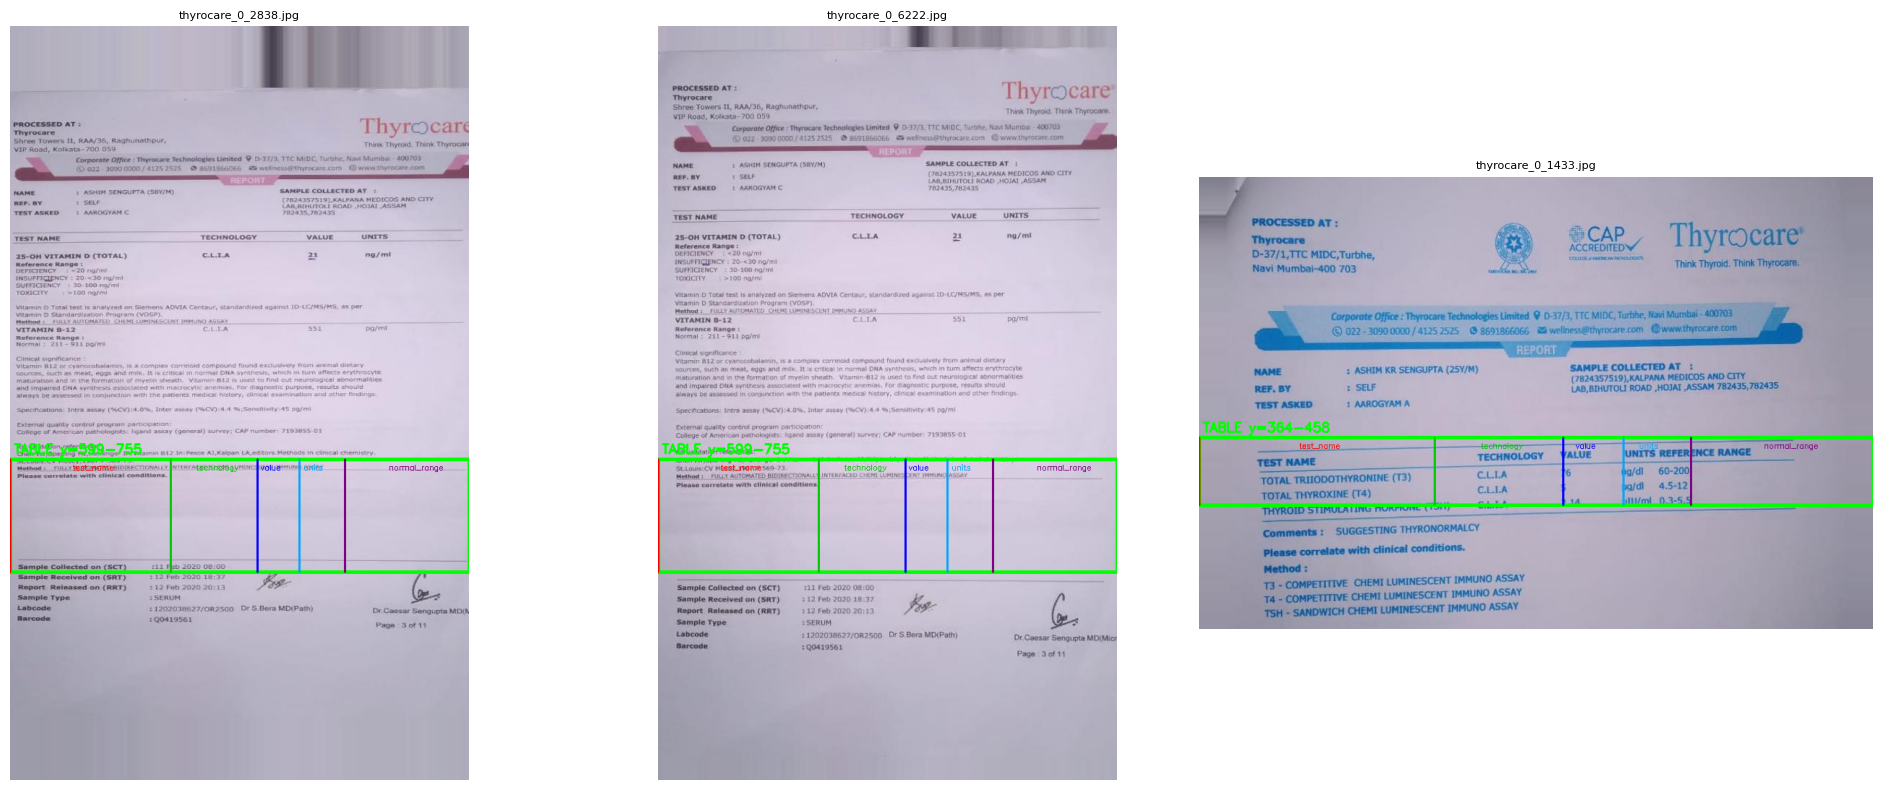

In [ ]:
import cv2, os, glob, numpy as np, random
import matplotlib.pyplot as plt

base    = '/content/drive/MyDrive/Custom_OCR'
img_dir = f'{base}/dataset/images'
lbl_dir = f'{base}/dataset/labels'

def make_label_fixed(img_path, lbl_path):
    img  = cv2.imread(img_path)
    h, w = img.shape[:2]
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # ── Find TEST NAME header row ──
    # It's a dark band that contains "TEST NAME | TECHNOLOGY | VALUE..."
    # From the verify image, it's around 55-65% from top
    header_y = None
    for y in range(int(h*0.45), int(h*0.75)):
        row_mean = np.mean(gray[y, int(w*0.05):int(w*0.95)])
        if row_mean < 110:
            header_y = y
            break

    if header_y is None:
        # Fallback
        header_y = int(h * 0.57)

    # Data rows start right after header
    data_y1 = header_y + 5

    # Data rows end before "Comments:" line
    # Scan for a dense text line after data rows
    data_y2 = data_y1 + int(h * 0.15)
    for y in range(data_y1 + int(h*0.04), data_y1 + int(h*0.20)):
        row = gray[y, int(w*0.02):int(w*0.30)]
        if np.mean(row) > 240:  # white/blank row = end of table
            data_y2 = y
            break

    data_y1 = max(0, data_y1)
    data_y2 = min(h, data_y2)

    # Normalized YOLO labels
    yc = ((data_y1 + data_y2) / 2) / h
    bh = (data_y2 - data_y1) / h

    cols = [
        (0, 0.00, 0.35),  # test_name
        (1, 0.35, 0.54),  # technology
        (2, 0.54, 0.63),  # value
        (3, 0.63, 0.73),  # units
        (4, 0.73, 1.00),  # normal_range
    ]
    lines = []
    for cls_id, x1r, x2r in cols:
        xc = (x1r + x2r) / 2
        bw = x2r - x1r
        lines.append(f"{cls_id} {xc:.6f} {yc:.6f} {bw:.6f} {bh:.6f}")

    with open(lbl_path, 'w') as f:
        f.write('\n'.join(lines))

    return data_y1, data_y2, h, w

# Generate all labels
images = glob.glob(f'{img_dir}/*.jpg') + glob.glob(f'{img_dir}/*.png')
for img_path in images:
    name = os.path.splitext(os.path.basename(img_path))[0]
    make_label_fixed(img_path, f'{lbl_dir}/{name}.txt')
print(f"✅ {len(images)} labels regenerated!")

# ── Verify on 3 images ──
col_x     = [0.00, 0.35, 0.54, 0.63, 0.73, 1.00]
col_names = ['test_name','technology','value','units','normal_range']
colors    = [(0,0,255),(0,200,0),(255,0,0),(255,165,0),(128,0,128)]

fig, axes = plt.subplots(1, 3, figsize=(20, 8))
for ax, img_path in zip(axes, random.sample(images, 3)):
    d_y1, d_y2, h, w = make_label_fixed(img_path, '/tmp/tmp.txt')
    img = cv2.imread(img_path).copy()

    cv2.rectangle(img,(0,d_y1),(w,d_y2),(0,255,0),3)
    cv2.putText(img,f"TABLE y={d_y1}-{d_y2}",
                (5,d_y1-8),cv2.FONT_HERSHEY_SIMPLEX,
                0.6,(0,255,0),2)

    for i in range(len(col_x)-1):
        x = int(w*col_x[i])
        cv2.line(img,(x,d_y1),(x,d_y2),colors[i],2)
        cx = int(w*(col_x[i]+col_x[i+1])/2)-25
        cv2.putText(img,col_names[i],(cx,d_y1+15),
                    cv2.FONT_HERSHEY_SIMPLEX,0.35,colors[i],1)

    ax.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
    ax.set_title(os.path.basename(img_path),fontsize=8)
    ax.axis('off')

plt.tight_layout()
out = f'{base}/results/label_verify3.jpg'
plt.savefig(out, dpi=120, bbox_inches='tight')
print(f"✅ Saved → results/label_verify3.jpg")
plt.show()

In [ ]:
from ultralytics import YOLO
import shutil, random, yaml, os, glob

base    = '/content/drive/MyDrive/Custom_OCR'
img_dir = f'{base}/dataset/images'
lbl_dir = f'{base}/dataset/labels'
images  = glob.glob(f'{img_dir}/*.jpg') + glob.glob(f'{img_dir}/*.png')

# Rebuild dataset folders
for folder in ['images/train','images/val','labels/train','labels/val']:
    os.makedirs(f'{base}/yolov8_dataset/{folder}', exist_ok=True)

random.shuffle(images)
split      = int(0.8 * len(images))
train_imgs = images[:split]
val_imgs   = images[split:]

def copy_split(img_list, split_name):
    for img_path in img_list:
        name = os.path.splitext(os.path.basename(img_path))[0]
        ext  = os.path.splitext(img_path)[1]
        lbl  = f'{lbl_dir}/{name}.txt'
        shutil.copy(img_path,
            f'{base}/yolov8_dataset/images/{split_name}/{name}{ext}')
        if os.path.exists(lbl):
            shutil.copy(lbl,
                f'{base}/yolov8_dataset/labels/{split_name}/{name}.txt')

copy_split(train_imgs, 'train')
copy_split(val_imgs,   'val')
print(f"✅ Train: {len(train_imgs)} | Val: {len(val_imgs)}")

# Train
model = YOLO('yolov8n.pt')
model.train(
    data     = f'{base}/yolov8_dataset/thyrocare.yaml',
    epochs   = 60,
    imgsz    = 640,
    batch    = 16,
    name     = 'thyrocare_v8_final',
    project  = f'{base}/models',
    exist_ok = True,
    patience = 15,
    device   = 0
)
print("🎉 Training complete!")

✅ Train: 80 | Val: 20
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Custom_OCR/yolov8_dataset/thyrocare.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=thyrocare_v8_final, nbs=64, nms=False, opset=None,

In [ ]:
from ultralytics import YOLO
import cv2, pytesseract, pandas as pd
import numpy as np, os, glob, re
from openpyxl import Workbook
from openpyxl.styles import PatternFill, Font, Alignment

base      = '/content/drive/MyDrive/Custom_OCR'
col_names = ['test_name','technology','value','units','normal_range']

# Load best model
model = YOLO(f'{base}/models/thyrocare_v8_final/weights/best.pt')
print("✅ Model loaded!")

# ── Corrections ──
CORRECTIONS = {
    r'C\.L[^I]*\.?[^A]*A': 'C.L.I.A',
    r'C\.LLA':              'C.L.I.A',
    r'C\.L\.LA':            'C.L.I.A',
    r'CLIA':                'C.L.I.A',
    r'CLZA':                'C.L.I.A',
    r'CALA':                'C.L.I.A',
    r'ng/d[il1]':           'ng/dl',
    r'ug/d[il1]':           'ug/dl',
    r'u[il1]u/m[il1]':      'uIU/ml',
    r'pg/m[il1]':           'pg/ml',
    r'va/d[il1]':           'ug/dl',
    r'na/d[il1]':           'ng/dl',
    r'60-20[01]':           '60-200',
    r'4\.5-1[234;]':        '4.5-12',
    r'0\.3-5\.[0-9]':       '0.3-5.5',
}

SKIP_ROWS = ['TEST NAME','TEST MAME','TESTMAME','TECHNOLOGY',
             'ASKED','REF.','NAME :','BY :','SAMPLE','REPORT',
             'CORPORATE','PROCESSED','COLLECT']

def correct_text(text):
    for pattern, replacement in CORRECTIONS.items():
        text = re.sub(pattern, replacement, text, flags=re.IGNORECASE)
    return text.strip()

def preprocess_crop(crop):
    crop  = cv2.resize(crop, None, fx=4, fy=4,
                       interpolation=cv2.INTER_CUBIC)
    gray  = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
    gray  = cv2.fastNlMeansDenoising(gray, h=10)
    k     = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]])
    sharp = cv2.filter2D(gray, -1, k)
    _, th = cv2.threshold(sharp, 0, 255,
                          cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return th

def run_ocr_final(image_path):
    img     = cv2.imread(image_path)
    h, w    = img.shape[:2]
    results = model(image_path, conf=0.3, verbose=False)
    boxes   = results[0].boxes
    if boxes is None or len(boxes) == 0:
        return None

    col_texts = {n: '' for n in col_names}
    for box in boxes:
        x1,y1,x2,y2 = map(int, box.xyxy[0].tolist())
        cls_name = col_names[int(box.cls[0])]
        x1=max(0,x1); y1=max(0,y1)
        x2=min(w,x2); y2=min(h,y2)
        crop = img[y1:y2, x1:x2]
        proc = preprocess_crop(crop)
        text = pytesseract.image_to_string(
            proc, config='--psm 6 --oem 3'
        ).strip()
        col_texts[cls_name] = text

    col_rows = {}
    max_rows = 0
    for name in col_names:
        lines = []
        for line in col_texts[name].split('\n'):
            line = correct_text(line.strip())
            if len(line) < 2:
                continue
            lines.append(line)
        col_rows[name] = lines
        max_rows = max(max_rows, len(lines))

    for name in col_names:
        while len(col_rows[name]) < max_rows:
            col_rows[name].append('')

    df = pd.DataFrame(col_rows, columns=col_names)
    df = df[df['test_name'].str.len() > 2]
    df = df[df['test_name'].str.contains('[A-Za-z]', regex=True)]
    mask = df['test_name'].str.upper().apply(
        lambda x: not any(s in x for s in SKIP_ROWS))
    df = df[mask].reset_index(drop=True)
    return df

# ── Process all 100 images ──
images      = glob.glob(f'{base}/dataset/images/*.jpg')
images     += glob.glob(f'{base}/dataset/images/*.png')
all_results = []
failed      = []

print(f"\n🔍 Processing {len(images)} images...\n")
for i, img_path in enumerate(images):
    name = os.path.basename(img_path)
    print(f"[{i+1}/{len(images)}] {name}", end=' → ')
    try:
        df = run_ocr_final(img_path)
        if df is not None and not df.empty:
            df['source_image'] = name
            all_results.append(df)
            print(f"✅ {len(df)} rows")
        else:
            failed.append(name)
            print("⚠️ No data")
    except Exception as e:
        failed.append(name)
        print(f"❌ {str(e)[:40]}")

# ── Save results ──
if all_results:
    final_df = pd.concat(all_results, ignore_index=True)
    final_df.to_csv(f'{base}/results/final_results.csv', index=False)

    wb = Workbook()
    ws = wb.active
    ws.title = "Lab Results"
    hdr_fill = PatternFill("solid", fgColor="1F4E79")
    hdr_font = Font(color="FFFFFF", bold=True, size=11)
    alt_fill = PatternFill("solid", fgColor="EBF3FB")
    headers  = col_names + ['source_image']

    for c, h in enumerate(headers, 1):
        cell = ws.cell(row=1, column=c,
                       value=h.upper().replace('_',' '))
        cell.fill      = hdr_fill
        cell.font      = hdr_font
        cell.alignment = Alignment(horizontal='center')

    for r, row in final_df.iterrows():
        for c, col in enumerate(headers, 1):
            cell = ws.cell(row=r+2, column=c,
                           value=str(row.get(col,'')))
            cell.alignment = Alignment(horizontal='left')
            if r % 2 == 0:
                cell.fill = alt_fill

    for i, w in enumerate([35,12,8,10,16,25], 1):
        ws.column_dimensions[
            ws.cell(row=1,column=i).column_letter].width = w

    wb.save(f'{base}/results/final_results.xlsx')

    print(f"\n✅ CSV + Excel saved to Drive!")
    print(f"\n📊 Summary:")
    print(f"   Total images : {len(images)}")
    print(f"   Successful   : {len(all_results)}")
    print(f"   Failed       : {len(failed)}")
    print(f"   Total rows   : {len(final_df)}")

    # Show sample output
    print(f"\n📋 Sample output (first 10 rows):")
    print(final_df[col_names].head(10).to_string(index=False))

✅ Model loaded!

🔍 Processing 100 images...

[1/100] thyrocare_0_36.jpg → ✅ 4 rows
[2/100] thyrocare_0_421.jpg → ✅ 5 rows
[3/100] thyrocare_0_122.jpg → ✅ 3 rows
[4/100] thyrocare_0_123.jpg → ✅ 3 rows
[5/100] thyrocare_0_447.jpg → ✅ 1 rows
[6/100] thyrocare_0_532.jpg → ✅ 4 rows
[7/100] thyrocare_0_517.jpg → ✅ 2 rows
[8/100] thyrocare_0_511.jpg → ✅ 1 rows
[9/100] thyrocare_0_640.jpg → ✅ 4 rows
[10/100] thyrocare_0_657.jpg → ✅ 1 rows
[11/100] thyrocare_0_838.jpg → ✅ 4 rows
[12/100] thyrocare_0_757.jpg → ✅ 1 rows
[13/100] thyrocare_0_912.jpg → ✅ 3 rows
[14/100] thyrocare_0_1001.jpg → ✅ 4 rows
[15/100] thyrocare_0_1248.jpg → ✅ 3 rows
[16/100] thyrocare_0_1174.jpg → ✅ 3 rows
[17/100] thyrocare_0_1374.jpg → ✅ 1 rows
[18/100] thyrocare_0_1433.jpg → ✅ 1 rows
[19/100] thyrocare_0_1915.jpg → ✅ 4 rows
[20/100] thyrocare_0_1711.jpg → ✅ 4 rows
[21/100] thyrocare_0_1861.jpg → ✅ 1 rows
[22/100] thyrocare_0_2177.jpg → ✅ 4 rows
[23/100] thyrocare_0_2300.jpg → ⚠️ No data
[24/100] thyrocare_0_2505.jpg → ✅

In [ ]:
from ultralytics import YOLO
import cv2, pytesseract, pandas as pd
import numpy as np, os, glob, random, re

base      = '/content/drive/MyDrive/Custom_OCR'
col_names = ['test_name','technology','value','units','normal_range']
model     = YOLO(f'{base}/models/thyrocare_v8_final/weights/best.pt')

# ── Common OCR corrections for lab reports ──
CORRECTIONS = {
    # Technology
    r'C\.L[^I]*\.?[^A]*A': 'C.L.I.A',
    r'CL[^I]*IA':           'C.L.I.A',
    r'CLIA':                'C.L.I.A',
    r'CLZA':                'C.L.I.A',
    r'C\.LLA':              'C.L.I.A',
    r'C\.L\.LA':            'C.L.I.A',
    r'CALA':                'C.L.I.A',
    # Units
    r'ng/d[il1]':           'ng/dl',
    r'ug/d[il1]':           'ug/dl',
    r'u[il1]u/m[il1]':      'uIU/ml',
    r'p[il1]l[il1]/m[il1]': 'pili/ml',
    r'pg/m[il1]':           'pg/ml',
    r'va/d[il1]':           'ug/dl',
    r'na/d[il1]':           'ng/dl',
    # Normal range
    r'60-20[01]':           '60-200',
    r'4\.5-1[234;]':        '4.5-12',
    r'0\.3-5\.[0-9]':       '0.3-5.5',
    # Remove header row artifacts
    r'TEST\s*MAME':         '',
    r'TestMAME':            '',
    r'__+':                 '',
    r'Tec[Hh]noto[a-z]+':  'TECHNOLOGY',
}

def correct_text(text):
    for pattern, replacement in CORRECTIONS.items():
        text = re.sub(pattern, replacement, text, flags=re.IGNORECASE)
    return text.strip()

def preprocess_crop(crop):
    """Enhanced preprocessing for better Tesseract accuracy"""
    # Upscale 4x
    crop = cv2.resize(crop, None, fx=4, fy=4,
                      interpolation=cv2.INTER_CUBIC)
    gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
    # Denoise
    gray = cv2.fastNlMeansDenoising(gray, h=10)
    # Sharpen
    kernel  = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]])
    sharp   = cv2.filter2D(gray, -1, kernel)
    # Threshold
    _, th   = cv2.threshold(sharp, 0, 255,
                            cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return th

def run_ocr_final(image_path):
    img     = cv2.imread(image_path)
    h, w    = img.shape[:2]
    results = model(image_path, conf=0.3, verbose=False)
    boxes   = results[0].boxes

    if boxes is None or len(boxes) == 0:
        return None

    col_texts = {n: '' for n in col_names}
    for box in boxes:
        x1,y1,x2,y2 = map(int, box.xyxy[0].tolist())
        cls_id   = int(box.cls[0])
        cls_name = col_names[cls_id]
        x1=max(0,x1); y1=max(0,y1)
        x2=min(w,x2); y2=min(h,y2)

        crop      = img[y1:y2, x1:x2]
        processed = preprocess_crop(crop)

        # Use PSM 6 for blocks of text
        text = pytesseract.image_to_string(
            processed,
            config='--psm 6 --oem 3'
        ).strip()
        col_texts[cls_name] = text

    # Split into rows + clean
    col_rows = {}
    max_rows = 0
    for name in col_names:
        lines = []
        for line in col_texts[name].split('\n'):
            line = line.strip()
            if len(line) < 2:
                continue
            line = correct_text(line)
            if len(line) < 2:
                continue
            lines.append(line)
        col_rows[name] = lines
        max_rows = max(max_rows, len(lines))

    # Pad columns
    for name in col_names:
        while len(col_rows[name]) < max_rows:
            col_rows[name].append('')

    df = pd.DataFrame(col_rows, columns=col_names)

    # Remove header rows + garbage rows
    df = df[df['test_name'].str.len() > 2]
    df = df[df['test_name'].str.contains('[A-Za-z]', regex=True)]
    df = df[~df['test_name'].str.upper().str.contains(
        'TEST NAME|TEST MAME|TESTMAME|TECHNOLOGY|ASKED|REF|NAME :|BY :|SAMPLE')]
    df = df.reset_index(drop=True)
    return df

print("✅ Final OCR pipeline ready!")

✅ Final OCR pipeline ready!


In [ ]:
from openpyxl import Workbook
from openpyxl.styles import PatternFill, Font, Alignment

images      = glob.glob(f'{base}/dataset/images/*.jpg')
images     += glob.glob(f'{base}/dataset/images/*.png')
all_results = []
failed      = []

print(f"🔍 Processing {len(images)} images...\n")

for i, img_path in enumerate(images):
    name = os.path.basename(img_path)
    print(f"[{i+1}/{len(images)}] {name}", end=' → ')
    try:
        df = run_ocr_final(img_path)
        if df is not None and not df.empty:
            df['source_image'] = name
            all_results.append(df)
            print(f"✅ {len(df)} rows")
        else:
            failed.append(name)
            print("⚠️ No data")
    except Exception as e:
        failed.append(name)
        print(f"❌ {str(e)[:40]}")

if all_results:
    final_df = pd.concat(all_results, ignore_index=True)

    # Save CSV
    csv_path = f'{base}/results/final_results.csv'
    final_df.to_csv(csv_path, index=False)
    print(f"\n✅ CSV saved!")

    # Save formatted Excel
    xlsx_path = f'{base}/results/final_results.xlsx'
    wb = Workbook()
    ws = wb.active
    ws.title = "Lab Results"

    # Header styling
    hdr_fill = PatternFill("solid", fgColor="1F4E79")
    hdr_font = Font(color="FFFFFF", bold=True, size=11)
    alt_fill = PatternFill("solid", fgColor="EBF3FB")

    headers = col_names + ['source_image']
    for col, h in enumerate(headers, 1):
        c = ws.cell(row=1, column=col, value=h.upper().replace('_',' '))
        c.fill = hdr_fill
        c.font = hdr_font
        c.alignment = Alignment(horizontal='center', vertical='center')

    for r_idx, row in final_df.iterrows():
        for c_idx, col in enumerate(headers, 1):
            val = str(row.get(col, ''))
            c   = ws.cell(row=r_idx+2, column=c_idx, value=val)
            c.alignment = Alignment(horizontal='left')
            if r_idx % 2 == 0:
                c.fill = alt_fill

    # Column widths
    widths = [35, 12, 8, 10, 16, 25]
    for i, width in enumerate(widths, 1):
        ws.column_dimensions[
            ws.cell(row=1,column=i).column_letter
        ].width = width

    wb.save(xlsx_path)

    print(f"✅ Excel saved!")
    print(f"\n📊 Final Summary:")
    print(f"   Total images    : {len(images)}")
    print(f"   Successful      : {len(all_results)}")
    print(f"   Failed          : {len(failed)}")
    print(f"   Total rows      : {len(final_df)}")
    if failed:
        print(f"\n⚠️ Failed images: {failed[:5]}")
else:
    print("❌ No results at all")

🔍 Processing 100 images...

[1/100] thyrocare_0_36.jpg → ✅ 4 rows
[2/100] thyrocare_0_421.jpg → ✅ 5 rows
[3/100] thyrocare_0_122.jpg → ✅ 3 rows
[4/100] thyrocare_0_123.jpg → ✅ 3 rows
[5/100] thyrocare_0_447.jpg → ✅ 1 rows
[6/100] thyrocare_0_532.jpg → ✅ 4 rows
[7/100] thyrocare_0_517.jpg → ✅ 2 rows
[8/100] thyrocare_0_511.jpg → ✅ 1 rows
[9/100] thyrocare_0_640.jpg → ✅ 4 rows
[10/100] thyrocare_0_657.jpg → ✅ 1 rows
[11/100] thyrocare_0_838.jpg → ✅ 4 rows
[12/100] thyrocare_0_757.jpg → ✅ 2 rows
[13/100] thyrocare_0_912.jpg → ✅ 3 rows
[14/100] thyrocare_0_1001.jpg → ✅ 4 rows
[15/100] thyrocare_0_1248.jpg → ✅ 3 rows
[16/100] thyrocare_0_1174.jpg → ✅ 3 rows
[17/100] thyrocare_0_1374.jpg → ✅ 1 rows
[18/100] thyrocare_0_1433.jpg → ✅ 1 rows
[19/100] thyrocare_0_1915.jpg → ✅ 4 rows
[20/100] thyrocare_0_1711.jpg → ✅ 4 rows
[21/100] thyrocare_0_1861.jpg → ✅ 1 rows
[22/100] thyrocare_0_2177.jpg → ✅ 4 rows
[23/100] thyrocare_0_2300.jpg → ⚠️ No data
[24/100] thyrocare_0_2505.jpg → ✅ 2 rows
[25/100] 

In [ ]:
from ultralytics import YOLO
import cv2, pytesseract, pandas as pd
import numpy as np, os, glob, re
from openpyxl import Workbook
from openpyxl.styles import PatternFill, Font, Alignment, Border, Side

base      = '/content/drive/MyDrive/Custom_OCR'
col_names = ['test_name','technology','value','units','normal_range']
model     = YOLO(f'{base}/models/thyrocare_v8_final/weights/best.pt')

def correct_text(text):
    text = re.sub(r'-\s*\n\s*', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    fixes = [
        (r'C\.?L\.?[IL1]?\.?[AI4]', 'C.L.I.A'),
        (r'PHOTO\s*-?\s*ME\s*-?\s*TRY', 'PHOTOMETRY'),
        (r'CALCULA\s*-?\s*TED',  'CALCULATED'),
        (r'[Uu][Gg]/[Dd][LlI1]', 'ug/dl'),
        (r'[Nn][Gg]/[Dd][LlI1]', 'ng/dl'),
        (r'[Uu][Il1][Uu]/[Mm][LlI1]', 'uIU/ml'),
        (r'[Pp][Gg]/[Mm][LlI1]', 'pg/ml'),
        (r'[Mm][Gg]/[Dd][LlI1]', 'mg/dl'),
        (r'[Gg][Mm]/[Dd][LlI1]', 'gm/dl'),
        (r'[Uu]/[Il1]$', 'U/I'),
        (r'va/d[il1]', 'ug/dl'),
        (r'na/d[il1]', 'ng/dl'),
        (r'60-20[01]', '60-200'),
        (r'4\.5-1[2Zz;]', '4.5-12'),
        (r'[Oo]\.3-5\.[0-9]', '0.3-5.5'),
    ]
    for p, r in fixes:
        text = re.sub(p, r, text, flags=re.IGNORECASE)
    return text.strip()

SKIP = ['TEST NAME','TEST MAME','TECHNOLOGY','VALUE','UNITS',
        'NORMAL','REFERENCE RANGE','ASKED','REF.','NAME :',
        'BY :','SAMPLE','REPORT','CORPORATE','PROCESSED',
        'COLLECT','THYROCARE','CAP ACCREDITED','COMMENTS',
        'METHOD','PLEASE CORRELATE','T3 -','T4 -','TSH -',
        'SANDWICH','COMPETITIVE','FULLY AUTO','BIDIRECTIONAL',
        'MOSBY','SPERLING','PESCE','KALPAN','CV):','INTRA',
        'LIGAND','SENSITIVITY','INTER ASSAY']

def should_skip(text):
    t = text.upper().strip()
    if len(t) < 3: return True
    return any(s in t for s in SKIP)

def preprocess(crop):
    crop  = cv2.resize(crop, None, fx=4, fy=4,
                       interpolation=cv2.INTER_CUBIC)
    gray  = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
    gray  = cv2.fastNlMeansDenoising(gray, h=8)
    k     = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]])
    sharp = cv2.filter2D(gray, -1, k)
    _, th = cv2.threshold(sharp, 0, 255,
                          cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return th

def find_data_table(img):
    """Find exact y-coords of data table using dark header band"""
    h, w  = img.shape[:2]
    gray  = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Find dark header band (TEST NAME row) between 40-72% of height
    header_y = None
    for y in range(int(h*0.40), int(h*0.72)):
        if np.mean(gray[y, int(w*0.05):int(w*0.95)]) < 110:
            header_y = y
            break
    if header_y is None:
        header_y = int(h * 0.52)

    # Data starts after header
    data_y1 = header_y + 6

    # Find end — blank row or next dark band
    data_y2 = data_y1 + int(h * 0.20)
    for y in range(data_y1 + int(h*0.03), data_y1 + int(h*0.25)):
        row_mean = np.mean(gray[y, int(w*0.02):int(w*0.40)])
        if row_mean > 242:
            data_y2 = y
            break

    return max(0,data_y1), min(h,data_y2)

def run_ocr_v6(image_path):
    img  = cv2.imread(image_path)
    h, w = img.shape[:2]

    # ── Use YOLO to find column x-coordinates ──
    results  = model(image_path, conf=0.25, verbose=False)
    boxes    = results[0].boxes

    # ── Find data table y-coordinates precisely ──
    data_y1, data_y2 = find_data_table(img)

    # Build column x-bounds from YOLO or use fixed ratios
    col_x = {}
    if boxes is not None and len(boxes) > 0:
        for box in boxes:
            x1,y1,x2,y2 = map(int, box.xyxy[0].tolist())
            cls_name = col_names[int(box.cls[0])]
            col_x[cls_name] = (max(0,x1), min(w,x2))

    # Fill missing columns with fixed ratios
    fixed = {
        'test_name':    (int(w*0.00), int(w*0.35)),
        'technology':   (int(w*0.35), int(w*0.54)),
        'value':        (int(w*0.54), int(w*0.63)),
        'units':        (int(w*0.63), int(w*0.73)),
        'normal_range': (int(w*0.73), int(w*1.00)),
    }
    for name in col_names:
        if name not in col_x:
            col_x[name] = fixed[name]

    # ── OCR each column using correct y-bounds ──
    col_texts = {}
    for name in col_names:
        x1c, x2c = col_x[name]
        # Use the precise table region only
        crop = img[data_y1:data_y2, x1c:x2c]
        if crop.size == 0:
            col_texts[name] = []
            continue

        proc = preprocess(crop)
        text = pytesseract.image_to_string(
            proc, config='--psm 6 --oem 3'
        ).strip()

        lines = []
        for line in text.split('\n'):
            line = correct_text(line.strip())
            if not should_skip(line) and len(line) > 1:
                lines.append(line)
        col_texts[name] = lines

    # Align to test_name row count
    max_rows = len(col_texts.get('test_name', []))
    if max_rows == 0:
        return None

    for name in col_names:
        while len(col_texts[name]) < max_rows:
            col_texts[name].append('')
        col_texts[name] = col_texts[name][:max_rows]

    df = pd.DataFrame(col_texts, columns=col_names)
    df = df[df['test_name'].str.len() > 3]
    df = df[df['test_name'].str.contains('[A-Za-z]', regex=True)]
    df = df.reset_index(drop=True)
    return df

print("✅ v6 OCR pipeline ready!")

✅ v6 OCR pipeline ready!


In [ ]:
images      = glob.glob(f'{base}/dataset/images/*.jpg')
images     += glob.glob(f'{base}/dataset/images/*.png')
all_results = []
failed      = []

print(f"🔍 Processing {len(images)} images...\n")
for i, img_path in enumerate(images):
    name = os.path.basename(img_path)
    print(f"[{i+1}/{len(images)}] {name}", end=' → ')
    try:
        df = run_ocr_v6(img_path)
        if df is not None and not df.empty:
            df['source_image'] = name
            all_results.append(df)
            print(f"✅ {len(df)} rows")
        else:
            failed.append(name)
            print("⚠️ No data")
    except Exception as e:
        failed.append(name)
        print(f"❌ {str(e)[:40]}")

if all_results:
    final_df = pd.concat(all_results, ignore_index=True)
    final_df.to_csv(f'{base}/results/clean_v2.csv', index=False)

    # Excel
    wb = Workbook()
    ws = wb.active
    ws.title = "Lab Results"
    hdr_fill = PatternFill("solid", fgColor="1F4E79")
    hdr_font = Font(color="FFFFFF", bold=True, size=11)
    alt_fill = PatternFill("solid", fgColor="EBF3FB")
    thin     = Side(style='thin', color='CCCCCC')
    bdr      = Border(left=thin,right=thin,top=thin,bottom=thin)
    headers  = col_names + ['source_image']

    for c, h in enumerate(headers, 1):
        cell = ws.cell(row=1, column=c,
                       value=h.upper().replace('_',' '))
        cell.fill=hdr_fill; cell.font=hdr_font
        cell.alignment=Alignment(horizontal='center')
        cell.border=bdr
    ws.row_dimensions[1].height = 20

    for r, row in final_df.iterrows():
        for c, col in enumerate(headers, 1):
            cell = ws.cell(row=r+2, column=c,
                           value=str(row.get(col,'')))
            cell.alignment=Alignment(horizontal='left')
            cell.border=bdr
            if r % 2 == 0: cell.fill=alt_fill
        ws.row_dimensions[r+2].height=16

    for i, width in enumerate([38,14,8,10,16,28],1):
        ws.column_dimensions[
            ws.cell(row=1,column=i).column_letter].width=width

    wb.save(f'{base}/results/clean_v2.xlsx')

    print(f"\n✅ Saved: clean_v2.csv + clean_v2.xlsx")
    print(f"\n📊 Summary:")
    print(f"   Total    : {len(images)}")
    print(f"   Success  : {len(all_results)}")
    print(f"   Failed   : {len(failed)}")
    print(f"   Rows     : {len(final_df)}")
    print(f"\n📋 Sample (first 15 rows):")
    print(final_df[col_names].head(15).to_string(index=False))

🔍 Processing 100 images...

[1/100] thyrocare_0_36.jpg → ✅ 5 rows
[2/100] thyrocare_0_421.jpg → ✅ 6 rows
[3/100] thyrocare_0_122.jpg → ✅ 4 rows
[4/100] thyrocare_0_123.jpg → ✅ 2 rows
[5/100] thyrocare_0_447.jpg → ✅ 4 rows
[6/100] thyrocare_0_532.jpg → ✅ 3 rows
[7/100] thyrocare_0_517.jpg → ✅ 3 rows
[8/100] thyrocare_0_511.jpg → ✅ 3 rows
[9/100] thyrocare_0_640.jpg → ✅ 3 rows
[10/100] thyrocare_0_657.jpg → ✅ 6 rows
[11/100] thyrocare_0_838.jpg → ✅ 4 rows
[12/100] thyrocare_0_757.jpg → ✅ 3 rows
[13/100] thyrocare_0_912.jpg → ✅ 3 rows
[14/100] thyrocare_0_1001.jpg → ✅ 3 rows
[15/100] thyrocare_0_1248.jpg → ✅ 2 rows
[16/100] thyrocare_0_1174.jpg → ✅ 2 rows
[17/100] thyrocare_0_1374.jpg → ✅ 5 rows
[18/100] thyrocare_0_1433.jpg → ✅ 3 rows
[19/100] thyrocare_0_1915.jpg → ✅ 4 rows
[20/100] thyrocare_0_1711.jpg → ✅ 2 rows
[21/100] thyrocare_0_1861.jpg → ✅ 6 rows
[22/100] thyrocare_0_2177.jpg → ✅ 2 rows
[23/100] thyrocare_0_2300.jpg → ✅ 6 rows
[24/100] thyrocare_0_2505.jpg → ✅ 3 rows
[25/100] th